# Competitive Positioning in the Smart TV Market

## Objective

This notebook integrates product-level characteristics with consumer review
insights to examine how Samsung, LG, Sony, TCL, and Hisense are positioned
within the Smart TV market.

Rather than evaluating brands using a single metric such as average star
rating, the analysis considers multiple dimensions of competition, including
product portfolio characteristics, consumer satisfaction, and perceived
strengths and pain points across key TV experience aspects.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

In [5]:
import os

print(os.listdir("."))

['.config', 'tv_products_analysis.parquet', 'tv_products.parquet', 'tv_reviews_clean.parquet', 'tv_reviews_analysis.parquet', 'tv_reviews.parquet', 'tv_products_clean.parquet', 'sample_data']


In [6]:
products = pd.read_parquet(
    "tv_products_analysis.parquet"
)

reviews = pd.read_parquet(
    "tv_reviews_analysis.parquet"
)

print("Products:", products.shape)
print("Reviews:", reviews.shape)

print("\nProduct columns:")
print(products.columns.tolist())

print("\nReview columns:")
print(reviews.columns.tolist())

Products: (1097, 20)
Reviews: (111191, 14)

Product columns:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'store', 'categories', 'details', 'parent_asin', 'brand', 'price_numeric', 'is_smart_tv', 'year', 'strong_smart_signal', 'is_bundle', 'screen_size', 'resolution', 'display_type']

Review columns:
['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'brand', 'review_date', 'review_year', 'text_clean', 'text_length']


In [7]:
print("\nProducts by brand:")
display(
    products["brand"]
    .value_counts()
)

print("\nReviews by brand:")
display(
    reviews["brand"]
    .value_counts()
)


Products by brand:


,count
brand,
Samsung,399
LG,308
Sony,204
TCL,94
Hisense,92



Reviews by brand:


,count
brand,
TCL,41559
Samsung,32662
LG,15108
Sony,12209
Hisense,9653


## 1. Product Portfolio Positioning

To understand how major Smart TV brands compete at the product level, this
section compares their portfolio size, screen-size profile, resolution mix,
and display-technology mix.

These measures describe the products represented in the analytical dataset
rather than current market share or sales performance.

In [8]:
brand_portfolio = (
    products.groupby("brand")
    .agg(
        products=("parent_asin", "nunique"),
        median_screen_size=("screen_size", "median"),
        avg_product_rating=("average_rating", "mean")
    )
)

# Resolution shares
brand_portfolio["4K_share"] = (
    products.assign(is_4k=products["resolution"].eq("4K"))
    .groupby("brand")["is_4k"]
    .mean() * 100
)

brand_portfolio["8K_share"] = (
    products.assign(is_8k=products["resolution"].eq("8K"))
    .groupby("brand")["is_8k"]
    .mean() * 100
)

# Display technology shares
for display in ["OLED", "QLED", "Mini-LED", "LED/LCD"]:
    brand_portfolio[f"{display}_share"] = (
        products.assign(
            indicator=products["display_type"].eq(display)
        )
        .groupby("brand")["indicator"]
        .mean() * 100
    )

brand_portfolio = brand_portfolio.round(2)

brand_portfolio

,products,median_screen_size,avg_product_rating,4K_share,8K_share,OLED_share,QLED_share,Mini-LED_share,LED/LCD_share
brand,,,,,,,,,
Hisense,92,50.0,3.98,70.65,1.09,0.00,15.22,3.26,38.04
LG,308,55.0,4.18,82.47,0.65,28.90,0.32,0.65,41.56
Samsung,399,55.0,4.22,87.47,3.76,2.76,49.62,2.01,35.84
Sony,204,65.0,4.27,92.65,2.45,29.41,0.00,2.45,62.75
TCL,94,54.6,4.20,58.51,2.13,0.00,14.89,7.45,54.26


In [12]:
aspect_ratings = pd.read_csv(
    "brand_aspect_ratings.csv",
    index_col=0
)

aspect_mentions = pd.read_csv(
    "brand_aspect_mentions.csv",
    index_col=0
)

aspect_ratings

,Samsung,LG,Sony,TCL,Hisense
aspect,,,,,
Customer Support,1.906482,2.217662,2.112019,2.003273,2.170160
Ease of Use & Setup,4.396837,4.450581,4.408033,4.467353,4.264267
Picture Quality,4.112466,4.247789,4.196889,4.090308,3.996506
Reliability,2.070086,2.345753,2.323096,2.032658,1.893768
Remote,3.844322,3.983105,3.965916,3.833550,3.403796
Smart Features & Apps,3.862063,3.898467,3.893752,3.955981,3.608831
Sound,3.926280,4.128725,4.057574,3.887132,3.835511
Value,3.880163,4.159761,3.999626,4.136422,3.954311


In [13]:
aspect_mentions

,Samsung,LG,Sony,TCL,Hisense
aspect,,,,,
Customer Support,6.187619,5.321684,7.019412,5.880796,8.401533
Ease of Use & Setup,12.969200,11.384697,14.071587,14.483024,11.799441
Picture Quality,42.168269,46.399259,52.125481,34.185134,41.510411
Reliability,6.028412,4.441356,6.667213,6.410164,7.313788
Remote,16.067601,12.536405,14.178065,14.831926,12.006630
Smart Features & Apps,16.802400,17.275616,23.204194,28.807238,23.225940
Sound,18.232196,21.544877,23.900401,17.652013,22.987672
Value,18.829221,21.088165,21.918257,30.125845,30.156428


## 2. Consumer Experience Positioning

Consumer review results from the previous analysis are summarized into four
interpretable dimensions of competitive positioning:

- **Core Product Experience:** Picture Quality and Sound
- **Usability & Smart Experience:** Ease of Use & Setup, Smart Features & Apps, and Remote
- **Ownership Experience:** Reliability and Customer Support
- **Value Perception:** Value-related review ratings

These dimensions summarize ratings among reviews that mention each experience.
They therefore represent consumer-perception signals rather than objective
measures of product quality.

In [14]:
consumer_positioning = pd.DataFrame(index=aspect_ratings.columns)

consumer_positioning["Core Product Experience"] = (
    aspect_ratings.loc[
        ["Picture Quality", "Sound"]
    ].mean()
)

consumer_positioning["Usability & Smart Experience"] = (
    aspect_ratings.loc[
        [
            "Ease of Use & Setup",
            "Smart Features & Apps",
            "Remote"
        ]
    ].mean()
)

consumer_positioning["Ownership Experience"] = (
    aspect_ratings.loc[
        ["Reliability", "Customer Support"]
    ].mean()
)

consumer_positioning["Value Perception"] = (
    aspect_ratings.loc["Value"]
)

consumer_positioning = consumer_positioning.round(3)

consumer_positioning

,Core Product Experience,Usability & Smart Experience,Ownership Experience,Value Perception
Samsung,4.019,4.034,1.988,3.880
LG,4.188,4.111,2.282,4.160
Sony,4.127,4.089,2.218,4.000
TCL,3.989,4.086,2.018,4.136
Hisense,3.916,3.759,2.032,3.954


## 3. Integrated Competitive Profile

Product portfolio characteristics and consumer experience dimensions are
combined to create a brand-level competitive profile.

The analysis keeps individual portfolio measures separate rather than
constructing an arbitrary overall technology or competitiveness score.
This preserves the meaning of each measure and makes differences between
brands easier to interpret.

In [15]:
# Select the most interpretable product-side positioning variables
portfolio_metrics = brand_portfolio[
    [
        "products",
        "median_screen_size",
        "4K_share",
        "OLED_share",
        "QLED_share",
        "Mini-LED_share"
    ]
].copy()

# Combine product portfolio and consumer experience measures
competitive_profile = portfolio_metrics.join(
    consumer_positioning
)

competitive_profile.round(2)

,products,median_screen_size,4K_share,OLED_share,QLED_share,Mini-LED_share,Core Product Experience,Usability & Smart Experience,Ownership Experience,Value Perception
brand,,,,,,,,,,
Hisense,92,50.0,70.65,0.00,15.22,3.26,3.92,3.76,2.03,3.95
LG,308,55.0,82.47,28.90,0.32,0.65,4.19,4.11,2.28,4.16
Samsung,399,55.0,87.47,2.76,49.62,2.01,4.02,4.03,1.99,3.88
Sony,204,65.0,92.65,29.41,0.00,2.45,4.13,4.09,2.22,4.00
TCL,94,54.6,58.51,0.00,14.89,7.45,3.99,4.09,2.02,4.14


In [16]:
consumer_relative = (
    consumer_positioning
    - consumer_positioning.mean()
)

consumer_relative = consumer_relative.round(3)

consumer_relative

,Core Product Experience,Usability & Smart Experience,Ownership Experience,Value Perception
Samsung,-0.029,0.018,-0.120,-0.146
LG,0.140,0.095,0.174,0.134
Sony,0.079,0.073,0.110,-0.026
TCL,-0.059,0.070,-0.090,0.110
Hisense,-0.132,-0.257,-0.076,-0.072


In [17]:
competitive_profile.round(2)

,products,median_screen_size,4K_share,OLED_share,QLED_share,Mini-LED_share,Core Product Experience,Usability & Smart Experience,Ownership Experience,Value Perception
brand,,,,,,,,,,
Hisense,92,50.0,70.65,0.00,15.22,3.26,3.92,3.76,2.03,3.95
LG,308,55.0,82.47,28.90,0.32,0.65,4.19,4.11,2.28,4.16
Samsung,399,55.0,87.47,2.76,49.62,2.01,4.02,4.03,1.99,3.88
Sony,204,65.0,92.65,29.41,0.00,2.45,4.13,4.09,2.22,4.00
TCL,94,54.6,58.51,0.00,14.89,7.45,3.99,4.09,2.02,4.14


In [18]:
consumer_relative

,Core Product Experience,Usability & Smart Experience,Ownership Experience,Value Perception
Samsung,-0.029,0.018,-0.120,-0.146
LG,0.140,0.095,0.174,0.134
Sony,0.079,0.073,0.110,-0.026
TCL,-0.059,0.070,-0.090,0.110
Hisense,-0.132,-0.257,-0.076,-0.072


In [21]:
import seaborn as sns
import os

FIGURE_DIR = "outputs/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

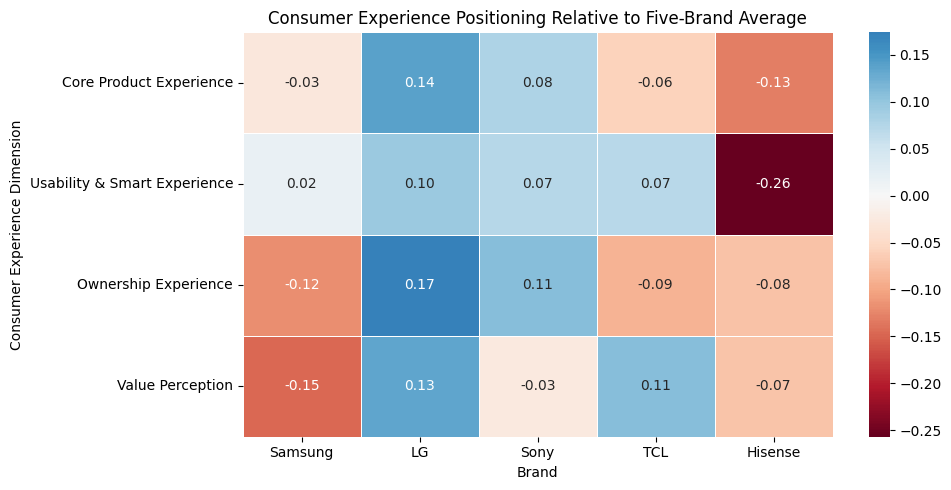

In [22]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    consumer_relative.T,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdBu",
    linewidths=0.5
)

plt.title(
    "Consumer Experience Positioning Relative to Five-Brand Average"
)
plt.xlabel("Brand")
plt.ylabel("Consumer Experience Dimension")

plt.savefig(
    f"{FIGURE_DIR}/05_consumer_experience_positioning_relative_to_brandav.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

### Interpretation

Consumer experience positioning varies meaningfully across brands. LG is
above the five-brand average across all four summarized experience dimensions,
with particularly strong relative results for ownership experience and core
product experience. Sony also performs above average across most experience
dimensions.

TCL shows a different profile: its core product experience is slightly below
the five-brand average, while usability and smart experience and value
perception are above average. Samsung remains relatively close to the market
average in core product and usability experience, but shows lower relative
ratings for ownership experience and value perception. Hisense shows the
largest relative weakness in usability and smart experience.

These differences reflect ratings among reviews that mention the underlying
experience aspects. They should therefore be interpreted as consumer-perception
signals rather than objective measurements of product performance.

In [24]:
display_mix = (
    pd.crosstab(
        products["brand"],
        products["display_type"],
        normalize="index"
    ) * 100
)

brand_order = [
    "Samsung",
    "LG",
    "Sony",
    "TCL",
    "Hisense"
]

display_mix = display_mix.reindex(brand_order)

display_mix.round(1)

display_type,LED/LCD,Mini-LED,NanoCell,OLED,QLED,Unknown
brand,,,,,,
Samsung,35.8,2.0,0.0,2.8,49.6,9.8
LG,41.6,0.6,7.8,28.9,0.3,20.8
Sony,62.7,2.5,0.0,29.4,0.0,5.4
TCL,54.3,7.4,0.0,0.0,14.9,23.4
Hisense,38.0,3.3,0.0,0.0,15.2,43.5


### Display Technology Portfolio

Display technology mix provides a product-side view of brand positioning.
The figure shows the share of each brand's analyzed Smart TV portfolio
classified into major display technology categories.

Because display technology could not be identified for every product,
the Unknown category is retained rather than assigning uncertain products
to a technology category.

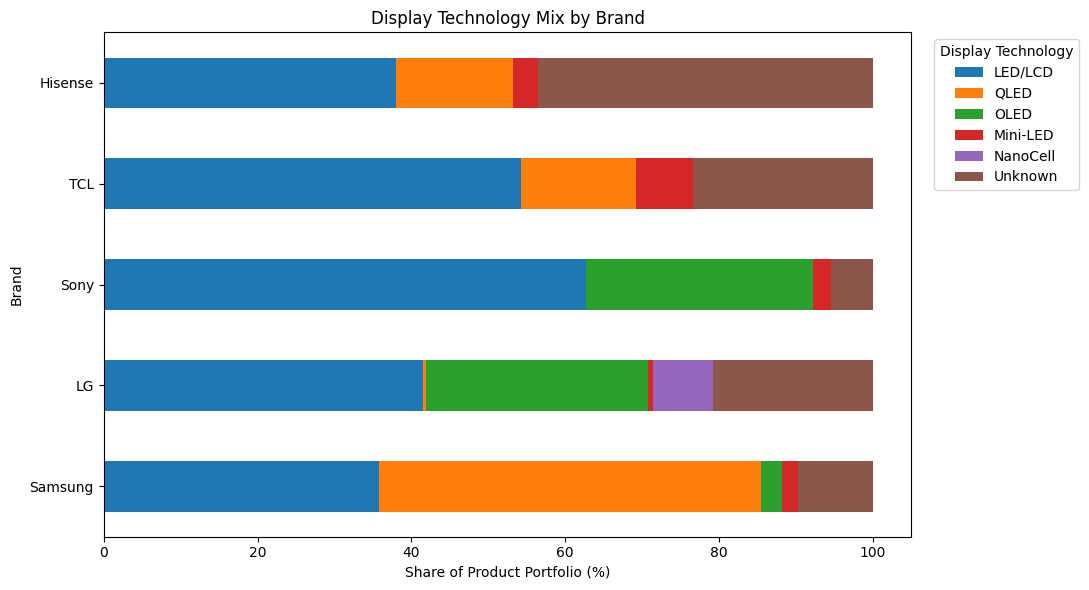

In [26]:
display_order = [
    "LED/LCD",
    "QLED",
    "OLED",
    "Mini-LED",
    "NanoCell",
    "Unknown"
]

display_mix_plot = display_mix[
    [col for col in display_order if col in display_mix.columns]
]

ax = display_mix_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 6)
)

ax.set_title("Display Technology Mix by Brand")
ax.set_xlabel("Share of Product Portfolio (%)")
ax.set_ylabel("Brand")

ax.legend(
    title="Display Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig(
    f"{FIGURE_DIR}/05_display_technology_mix_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()

### Interpretation

The product portfolios show distinct technology mixes across the five brands.
Samsung has the strongest identified concentration in QLED products, which
account for approximately half of its analyzed portfolio. LG and Sony show
substantial OLED presence, while Sony also has the largest median screen size
and the highest 4K share in the analytical sample. TCL shows the largest
Mini-LED share, although LED/LCD remains the largest identified category in
its portfolio.

The amount of unclassified display technology differs considerably by brand,
particularly for Hisense and TCL. Technology shares should therefore be
interpreted as characteristics of the products represented and successfully
classified in this dataset, rather than complete measures of each brand's
historical or current product lineup.

## 4. Competitive Positioning Summary

Combining product portfolio characteristics with consumer experience signals
reveals different competitive profiles across the five Smart TV brands.
Rather than assigning a single overall ranking, the following profiles
highlight the dimensions on which each brand is differentiated within the
analytical sample.

In [27]:
positioning_summary = pd.DataFrame({
    "Portfolio Signal": {
        "Samsung": "Largest portfolio; QLED-heavy mix",
        "LG": "Broad portfolio; substantial OLED presence",
        "Sony": "Largest median screen size; high 4K and OLED presence",
        "TCL": "Smaller portfolio; relatively high Mini-LED share",
        "Hisense": "Smaller portfolio; high display-type uncertainty"
    },

    "Consumer Experience Signal": {
        "Samsung": "Near average core/usability; weaker ownership and value signals",
        "LG": "Above average across all four experience dimensions",
        "Sony": "Strong core product and ownership experience signals",
        "TCL": "Above average usability/smart and value signals",
        "Hisense": "Weaker usability/smart and core product signals"
    }
})

positioning_summary

,Portfolio Signal,Consumer Experience Signal
Samsung,Largest portfolio; QLED-heavy mix,Near average core/usability; weaker ownership and value signals
LG,Broad portfolio; substantial OLED presence,Above average across all four experience dimensions
Sony,Largest median screen size; high 4K and OLED presence,Strong core product and ownership experience signals
TCL,Smaller portfolio; relatively high Mini-LED share,Above average usability/smart and value signals
Hisense,Smaller portfolio; high display-type uncertainty,Weaker usability/smart and core product signals


## 5. Strategic Implications

The combined analysis suggests that Smart TV brands compete through different
combinations of product technology and consumer experience rather than along
a single dimension of overall quality.

**Samsung** has the largest product portfolio in the analytical sample and a
distinctive QLED-heavy technology mix. However, its consumer experience
ratings remain close to the five-brand average for core product and
usability/smart experience, while value perception and ownership experience
are below the five-brand average. This suggests an opportunity to strengthen
the consumer value proposition and post-purchase experience alongside
technology-focused product differentiation.

**LG** combines substantial OLED presence with above-average consumer ratings
across all four summarized experience dimensions. Its strongest relative
advantages appear in core product experience and ownership experience,
suggesting that product technology and consumer experience reinforce one
another in the analyzed review data.

**Sony** has the largest median screen size and the highest 4K share in the
analytical sample, together with substantial OLED presence. Consumer reviews
also show above-average core product and ownership experience signals. This
creates a relatively consistent positioning around the core viewing and
product experience.

**TCL** shows a different competitive profile. Although its analyzed portfolio
is smaller and has a lower 4K share, it has the highest Mini-LED share and
above-average consumer signals for usability/smart experience and value.
These results suggest differentiation through accessible smart-TV experience
and perceived value rather than through portfolio breadth alone.

**Hisense** has a smaller analyzed portfolio and comparatively weaker consumer
signals in core product and especially usability/smart experience. These
results point to potential opportunities around usability, smart features,
and the broader ownership experience. However, its high share of products
with unclassified display technology makes product-portfolio comparisons
particularly uncertain.

## Limitations

Several limitations should be considered when interpreting the competitive
positioning results.

First, the dataset represents Amazon products and reviews associated with the
2015–2023 analytical period and should not be interpreted as a measure of the
current Smart TV market, market share, or sales performance.

Second, review volume is highly uneven across brands and products. In
particular, TCL reviews are heavily concentrated among a relatively small
number of products. Brand-level review results may therefore be influenced by
a few highly reviewed models.

Third, consumer experience aspects are identified from review language.
An aspect rating represents the average star rating of reviews that mention
that experience; it is not a direct measurement of the objective quality of
the underlying product attribute. Consumers may also be more likely to
mention reliability or customer support when they experience a problem.

Fourth, product metadata is incomplete. Price coverage was too low to support
reliable price-based positioning, and display technology could not be
classified for every product. Unknown classifications were therefore retained
rather than inferred.

Finally, the analysis is observational. Relationships between product
attributes, review topics, and ratings should be interpreted as associations
and consumer-perception signals rather than causal effects.

## Conclusion

This analysis shows that competitive positioning in the Smart TV market cannot
be explained by product specifications or average ratings alone. Product
portfolio strategies differ substantially across brands, but those differences
do not always translate directly into the same patterns of consumer experience.

Picture and core viewing experience remain important components of consumer
satisfaction, while usability, value, reliability, and customer support reveal
additional dimensions of differentiation. The combined product and review
analysis therefore suggests that competitive advantage in the Smart TV market
depends not only on what technologies brands offer, but also on how consumers
experience those products throughout setup, everyday use, and ownership.

By integrating product metadata with large-scale review analysis, the project
provides a multidimensional view of how major Smart TV brands are positioned
within the Amazon dataset.

In [28]:
import os

os.makedirs("outputs/tables", exist_ok=True)

competitive_profile.to_csv(
    "outputs/tables/competitive_profile.csv"
)

consumer_relative.to_csv(
    "outputs/tables/consumer_relative_positioning.csv"
)

positioning_summary.to_csv(
    "outputs/tables/brand_positioning_summary.csv"
)

print("Competitive positioning outputs saved.")

Competitive positioning outputs saved.
